In [54]:
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt

from IPython.core.pylabtools import figsize

In [55]:
data = pd.read_csv('data4.csv')
data.head()

,link,name,release_date,developers,genre,price,discount,dlc,tags,rating,...,stores,id_games,achievements_count,a_count,series_count,dev_team_count,rating_norm,reviews_log,reviews_norm,score
0,https://store.steampowered.com/app/730/Counter...,Counter-Strike 2,2012-08-21,Valve,"['Action', 'Free To Play']",Free To Play,0%,1.0,"['FPS', 'Shooter', 'Multiplayer', 'Competitive...",3.57,...,['Steam'],965470,0.0,0.0,0.0,1.0,0.739130,5.379897,0.604780,0.651803
1,https://store.steampowered.com/app/2868840/Sla...,Slay the Spire 2,2026-03-05,Mega Crit,"['Indie', 'Strategy', 'Early Access']","22,99€",0%,0.0,"['Strategy', 'Roguelike', 'Card Game', 'Deckbu...",0.00,...,['Steam'],994601,0.0,0.0,1.0,1.0,0.000000,1.791759,0.201420,0.130923
2,https://store.steampowered.com/app/2050650/Res...,Resident Evil 4,2023-03-24,"CAPCOM Co., Ltd.","['Action', 'Adventure']","100,24€",-60%,27.0,"['Horror', 'Action', 'Survival Horror', 'Third...",4.58,...,"['Steam', 'PlayStation Store']",795632,34.0,0.0,28.0,7.0,0.948240,6.455199,0.725660,0.803563
3,https://store.steampowered.com/app/1172470/Ape...,Apex Legends™,2020-11-04,Respawn,"['Action', 'Adventure', 'Free To Play']",Free To Play,0%,0.0,"['Free to Play', 'Battle Royale', 'Multiplayer...",3.63,...,"['Steam', 'PlayStation Store', 'Xbox Store', '...",290856,12.0,21.0,1.0,3.0,0.751553,7.799753,0.876807,0.832968
4,https://store.steampowered.com/app/230410/Warf...,Warframe,2013-03-25,Digital Extremes,"['Action', 'RPG', 'Free To Play']",Free To Play,0%,17.0,"['Free to Play', 'Looter Shooter', 'Action RPG...",3.42,...,"['Steam', 'PlayStation Store', 'Xbox Store', '...",766,259.0,0.0,0.0,14.0,0.708075,7.663408,0.861480,0.807788


Проверим, как влияет на успех игры то, кто ее создавал.

Для начала проверим, влияет ли количество человек в команде разработки на успех игры. Для этого расмотрим признак dev_team_count.

In [56]:
data['dev_team_count'].describe()

count    7423.000000
mean        1.836589
std         5.195488
min         0.000000
25%         0.000000
50%         0.000000
75%         1.000000
max        69.000000
Name: dev_team_count, dtype: float64

Text(0, 0.5, 'Количество команд')

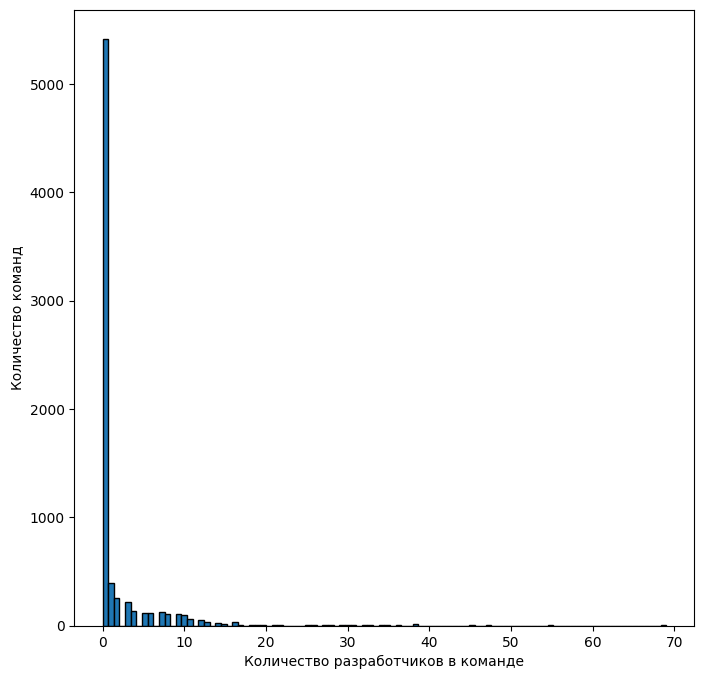

In [57]:
figsize(8, 8)

plt.hist(data['dev_team_count'], bins = 100, edgecolor = 'k')

plt.xlabel('Количество разработчиков в команде')
plt.ylabel('Количество команд')

Очевидно, что у нас не может быть команд разработки, где 0 человек, поэтому удалим эти значения для последующего анализа.

In [58]:
# Сделаем копию нашего датасета для того, чтобы ничего не испортить
data_dev = data.copy()

In [59]:
data_dev = data_dev[['name', 'developers', 'dev_team_count', 'score']]
data_dev = data_dev[data_dev['dev_team_count']>0]
data_dev

,name,developers,dev_team_count,score
0,Counter-Strike 2,Valve,1.0,0.651803
1,Slay the Spire 2,Mega Crit,1.0,0.130923
2,Resident Evil 4,"CAPCOM Co., Ltd.",7.0,0.803563
3,Apex Legends™,Respawn,3.0,0.832968
4,Warframe,Digital Extremes,14.0,0.807788
...,...,...,...,...
7409,TimeShift™,Saber Interactive,3.0,0.682542
7411,Blades of Time,Gaijin Entertainment Corporation,1.0,0.573396
7412,Sheltered,"Unicube, Team 17 Digital Ltd",2.0,0.576853
7414,Megadimension Neptunia VII,"Idea Factory, Compile Heart",8.0,0.517282


Text(0, 0.5, 'Количество команд')

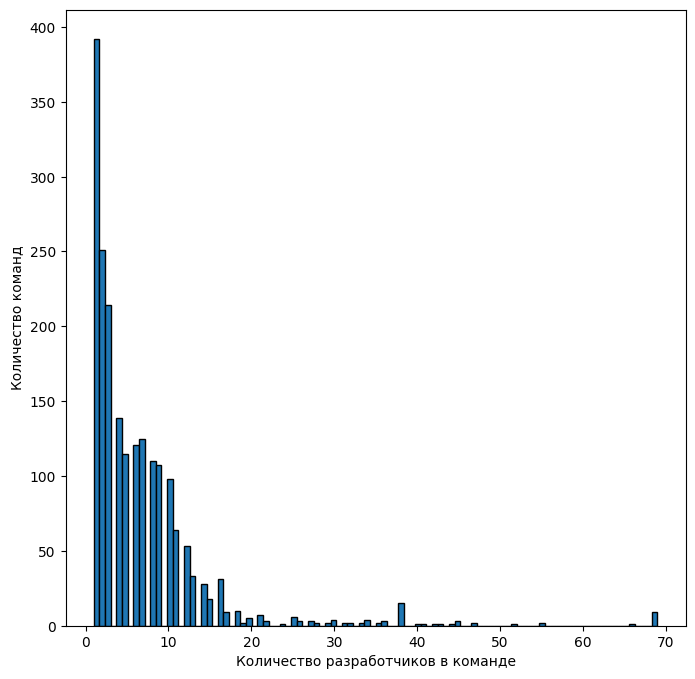

In [60]:
figsize(8, 8)

plt.hist(data_dev['dev_team_count'], bins = 100, edgecolor = 'k')

plt.xlabel('Количество разработчиков в команде')
plt.ylabel('Количество команд')

Видим, что большинство игр на нашем рынке создаются маленькими командами. Большие команды есть, но их значительно меньше. 

In [61]:
data_dev['dev_team_count'].describe()

count    2009.000000
mean        6.785963
std         8.134452
min         1.000000
25%         2.000000
50%         5.000000
75%         9.000000
max        69.000000
Name: dev_team_count, dtype: float64

Есть предположение, что из-за сильного перекоса данных в сторону маленьких значений тяжело будет отследить зависимость score от количество разработчиков, так как у маленьких команд будет сильный разброс по рейтингу, а у больших нет. Проверим.

In [62]:
# Воспользуемся методом corr(), выберем столбец с целевой меткой 'score' и посмотрим корреляцию
data_dev.corr(numeric_only = True)[['dev_team_count','score']]

,dev_team_count,score
dev_team_count,1.000000,0.206456
score,0.206456,1.000000


Text(0.5, 1.0, 'Зависимость успешности от размера команды')

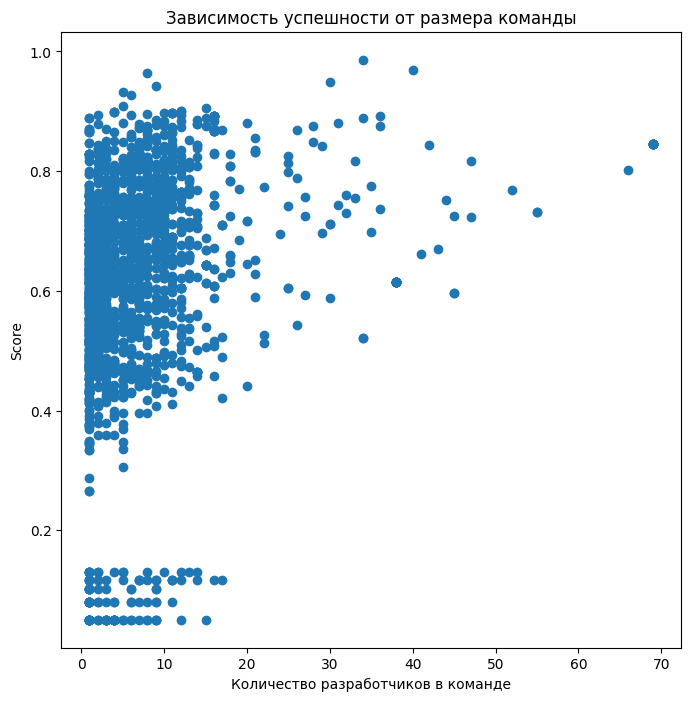

In [63]:
fig, ax = plt.subplots()
ax.scatter(data_dev['dev_team_count'], data_dev['score'])

ax.set_xlabel('Количество разработчиков в команде')
ax.set_ylabel('Score')
ax.set_title('Зависимость успешности от размера команды')

Видим, что данные сильно не сбалансированы. Тяжело отследить тренд из-за того, что почти все точки сосредоточены слева. Попробуем поделить количество разработчиков на группы по количеству человек, чтобы снизить шум и отследить зависимость.

In [64]:
def group(x):
    if x <= 2:
        return '1-2'
    elif x <= 5:
        return '3-5'
    elif x <= 10:
        return '6-10'
    elif x <= 20:
        return '11-20'
    else:
        return '21-70'

data_dev['group'] = data_dev['dev_team_count'].apply(group)

In [87]:
group_dev = data_dev.groupby('group').agg({
    'name': ['count'],
    'score': ['mean', 'median', 'min', 'max']
    })

group_dev.columns = ['games_count', 'mean_score', 'median_score', 'min_score', 'max_score']
group_dev = group_dev.reset_index()

group_dev = group_dev.sort_values('group', key=lambda x: x.str.split('-').str[0].astype(int))
group_dev

,group,games_count,mean_score,median_score,min_score,max_score
0,1-2,643,0.575627,0.601458,0.050648,0.894008
3,3-5,468,0.623328,0.663225,0.050648,0.932947
4,6-10,561,0.653821,0.695441,0.050648,0.963342
1,11-20,253,0.673235,0.689458,0.050648,0.905841
2,21-70,84,0.730980,0.733558,0.513023,0.986232


Стоит отметить, что у больших студий довольно высокий минимальный балл score. Можно предположить, что они делают меньше игр, но результат у них стабильнее. Также у самых маленьких команд максимальная оценка самая низкая, как и среднее с медианой, вероятно, это не самая выгодная стратегия.

Text(0, 0.5, 'Score')

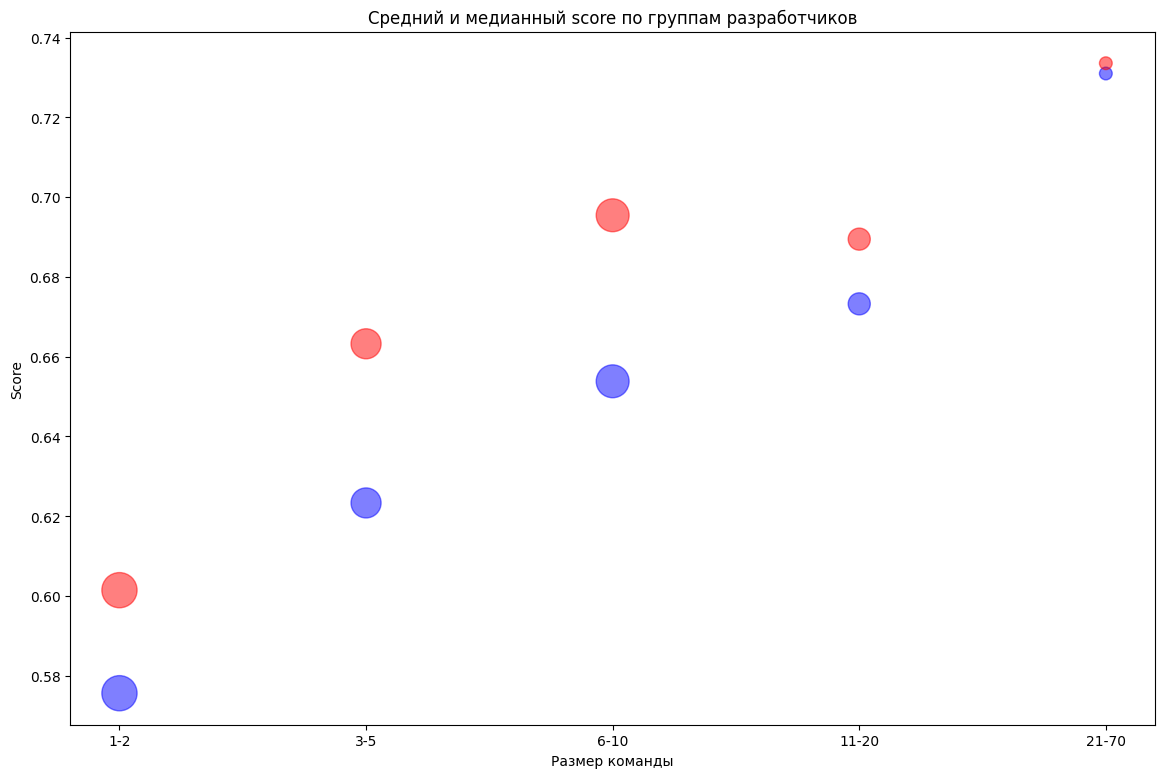

In [83]:
fig, ax = plt.subplots(figsize=(14, 9))

ax.scatter(
    group_dev['group'],
    group_dev['mean_score'],
    s=group_dev['teams_count'],
    alpha=0.5,
    c='blue',
    label='mean'
)

ax.scatter(
    group_dev['group'],
    group_dev['median_score'],
    s=group_dev['teams_count'],
    alpha=0.5,
    c='red',
    label='mean'
)

ax.set_title('Средний и медианный score по группам разработчиков')
ax.set_xlabel('Размер команды')
ax.set_ylabel('Score')

Действительно видна практически линейная зависимость и среднего (ура, все было не зря), и медианы score от количества человек в команде. Делаем вывод, что с увеличением количества человек в команде средняя и медианная оценки растут.

Далее рассмотрим как разработчик/разработчики, который(-ые) занимался(-ись) разработкой игры, влияет(-ют) на ее успех. Есть ли разработчики, которые стабильно делают хорошие игры, или стабильно плохие :)

In [86]:
group_developers = data_dev.groupby('developers').agg({
    'name': ['count'],
    'score': ['mean', 'median', 'min', 'max']
    })

group_developers.columns = ['games_count', 'mean_score', 'median_score', 'min_score', 'max_score']
group_developers = group_developers.reset_index()
group_developers

,developers,games_count,mean_score,median_score,min_score,max_score
0,07th Expansion,9,0.536388,0.541303,0.432289,0.592675
1,100 Cats,1,0.612361,0.612361,0.612361,0.612361
2,11 bit studios,2,0.748447,0.748447,0.680680,0.816213
3,14° East,1,0.669182,0.669182,0.669182,0.669182
4,2D BOY,1,0.783918,0.783918,0.783918,0.783918
...,...,...,...,...,...,...
981,ustwo games,2,0.750361,0.750361,0.720685,0.780036
982,uvula LLC,1,0.050648,0.050648,0.050648,0.050648
983,"Çağatay Demir, Doğukan Şahin",1,0.736202,0.736202,0.736202,0.736202
984,开心茶房,1,0.101296,0.101296,0.101296,0.101296


Можно заметить, что разработчики у нас идут списком через запятую (все, кто работал над какой-то определенной игрой из списка) - это не очень удобно для анализа конкретных разрабов. Попробуем их разделить.

Для этого использовала информацию из источника: https://sky.pro/wiki/python/razdelyaem-znacheniya-v-stroke-data-frame-metod-split-v-pandas/

In [91]:
data_dev['developers'] = data_dev['developers'].str.split(',')
data_dev = data_dev.explode('developers')
data_dev.head()

,name,developers,dev_team_count,score,group
0,Counter-Strike 2,Valve,1.0,0.651803,1-2
1,Slay the Spire 2,Mega Crit,1.0,0.130923,1-2
2,Resident Evil 4,CAPCOM Co.,7.0,0.803563,6-10
2,Resident Evil 4,Ltd.,7.0,0.803563,6-10
3,Apex Legends™,Respawn,3.0,0.832968,3-5


In [99]:
group_developers = data_dev.groupby('developers').agg({
    'name': ['count'],
    'score': ['mean', 'median', 'min', 'max']
    })

group_developers.columns = ['games_count', 'mean_score', 'median_score', 'min_score', 'max_score']
group_developers = group_developers.reset_index()
group_developers

,developers,games_count,mean_score,median_score,min_score,max_score
0,& Windows Update),1,0.815700,0.815700,0.815700,0.815700
1,2K Australia,1,0.849477,0.849477,0.849477,0.849477
2,2K China,1,0.849477,0.849477,0.849477,0.849477
3,343 Industries,1,0.643379,0.643379,0.643379,0.643379
4,3DO,1,0.050648,0.050648,0.050648,0.050648
...,...,...,...,...,...,...
1088,ustwo games,2,0.750361,0.750361,0.720685,0.780036
1089,uvula LLC,1,0.050648,0.050648,0.050648,0.050648
1090,Çağatay Demir,1,0.736202,0.736202,0.736202,0.736202
1091,开心茶房,1,0.101296,0.101296,0.101296,0.101296


Посмотрим на топ 10 разработчиков по средней оценке.

In [93]:
group_developers = group_developers.sort_values('mean_score', ascending=False)

group_developers.head(10)

,developers,games_count,mean_score,median_score,min_score,max_score
230,Virtual Programming (Linux),1,0.927190,0.927190,0.927190,0.927190
601,Irrational Games,1,0.927190,0.927190,0.927190,0.927190
613,JustTomcuk,1,0.901153,0.901153,0.901153,0.901153
946,Team Cherry,3,0.898612,0.898612,0.898612,0.898612
128,Massive Entertainment,1,0.894421,0.894421,0.894421,0.894421
237,and Ubisoft Shanghai,1,0.894421,0.894421,0.894421,0.894421
768,Playdead,2,0.893801,0.893801,0.892517,0.895086
381,ConcernedApe,2,0.889494,0.889494,0.889494,0.889494
353,Campo Santo,1,0.884598,0.884598,0.884598,0.884598
921,Studio MDHR Entertainment Inc.,1,0.874892,0.874892,0.874892,0.874892


Интересно, но почти у всего топа очень маленькое количество игр, может, им просто повезло? Посмотрим на более стабильных лидеров.

In [ ]:
group_developers = group_developers[group_developers['games_count'] >= 10].sort_values('mean_score', ascending=False)

group_developers.head(10)

,developers,games_count,mean_score,median_score,min_score,max_score
994,Treyarch,12,0.819374,0.844701,0.711493,0.844701
18,Aspyr (Linux),18,0.798723,0.832942,0.493559,0.883315
20,Aspyr (Mac),32,0.785469,0.832942,0.493559,0.883315
1037,Valve,17,0.782051,0.807799,0.554929,0.969335
1015,Ubisoft Montreal,30,0.779099,0.793133,0.456837,0.905841
482,Firaxis Games,22,0.762997,0.832942,0.493559,0.867460
69,Feral Interactive (Linux),12,0.761836,0.785456,0.537376,0.901153
312,Behaviour Interactive Inc.,19,0.754440,0.758734,0.677139,0.758734
732,OVERKILL - a Starbreeze Studio.,12,0.751984,0.729459,0.729459,0.819559
1005,Ubisoft,15,0.748295,0.757793,0.422927,0.825509


Для определения еще более стабильных лидеров отсортируем по медианному значению.

In [105]:
group_developers = group_developers[group_developers['games_count'] >= 10].sort_values('median_score', ascending=False)

group_developers.head(10)

,developers,games_count,mean_score,median_score,min_score,max_score
994,Treyarch,12,0.819374,0.844701,0.711493,0.844701
20,Aspyr (Mac),32,0.785469,0.832942,0.493559,0.883315
482,Firaxis Games,22,0.762997,0.832942,0.493559,0.867460
18,Aspyr (Linux),18,0.798723,0.832942,0.493559,0.883315
1037,Valve,17,0.782051,0.807799,0.554929,0.969335
1015,Ubisoft Montreal,30,0.779099,0.793133,0.456837,0.905841
69,Feral Interactive (Linux),12,0.761836,0.785456,0.537376,0.901153
316,Bethesda Game Studios,11,0.745204,0.784407,0.525253,0.942227
670,Maxis,17,0.665233,0.782099,0.130923,0.782099
312,Behaviour Interactive Inc.,19,0.754440,0.758734,0.677139,0.758734


Значения весьма схожи, Treyarch - все также лидер!

Посмотрим также на стабильный антитоп (не будем звать их в команду).

In [107]:
group_developers = group_developers[group_developers['games_count'] >= 10].sort_values('mean_score')

group_developers.head(10)

,developers,games_count,mean_score,median_score,min_score,max_score
723,Nihon Falcom,24,0.459639,0.557601,0.050648,0.672344
275,Anvil Game Studios,10,0.469952,0.469952,0.469952,0.469952
114,LLC,10,0.479353,0.502716,0.080275,0.644799
617,KOEI TECMO GAMES CO.,12,0.496609,0.471409,0.369335,0.700601
485,Firefly Studios,10,0.497649,0.531494,0.050648,0.708019
379,Colossal Order,10,0.500381,0.690492,0.050648,0.834990
116,LTD.,29,0.515721,0.496712,0.080275,0.892074
893,Spike Chunsoft Co.,14,0.550708,0.601255,0.050648,0.756145
1003,Two Point Studios,12,0.580257,0.548441,0.117601,0.710968
898,Square Enix,34,0.588903,0.615649,0.101296,0.879026


<Axes: xlabel='developers', ylabel='mean_score'>

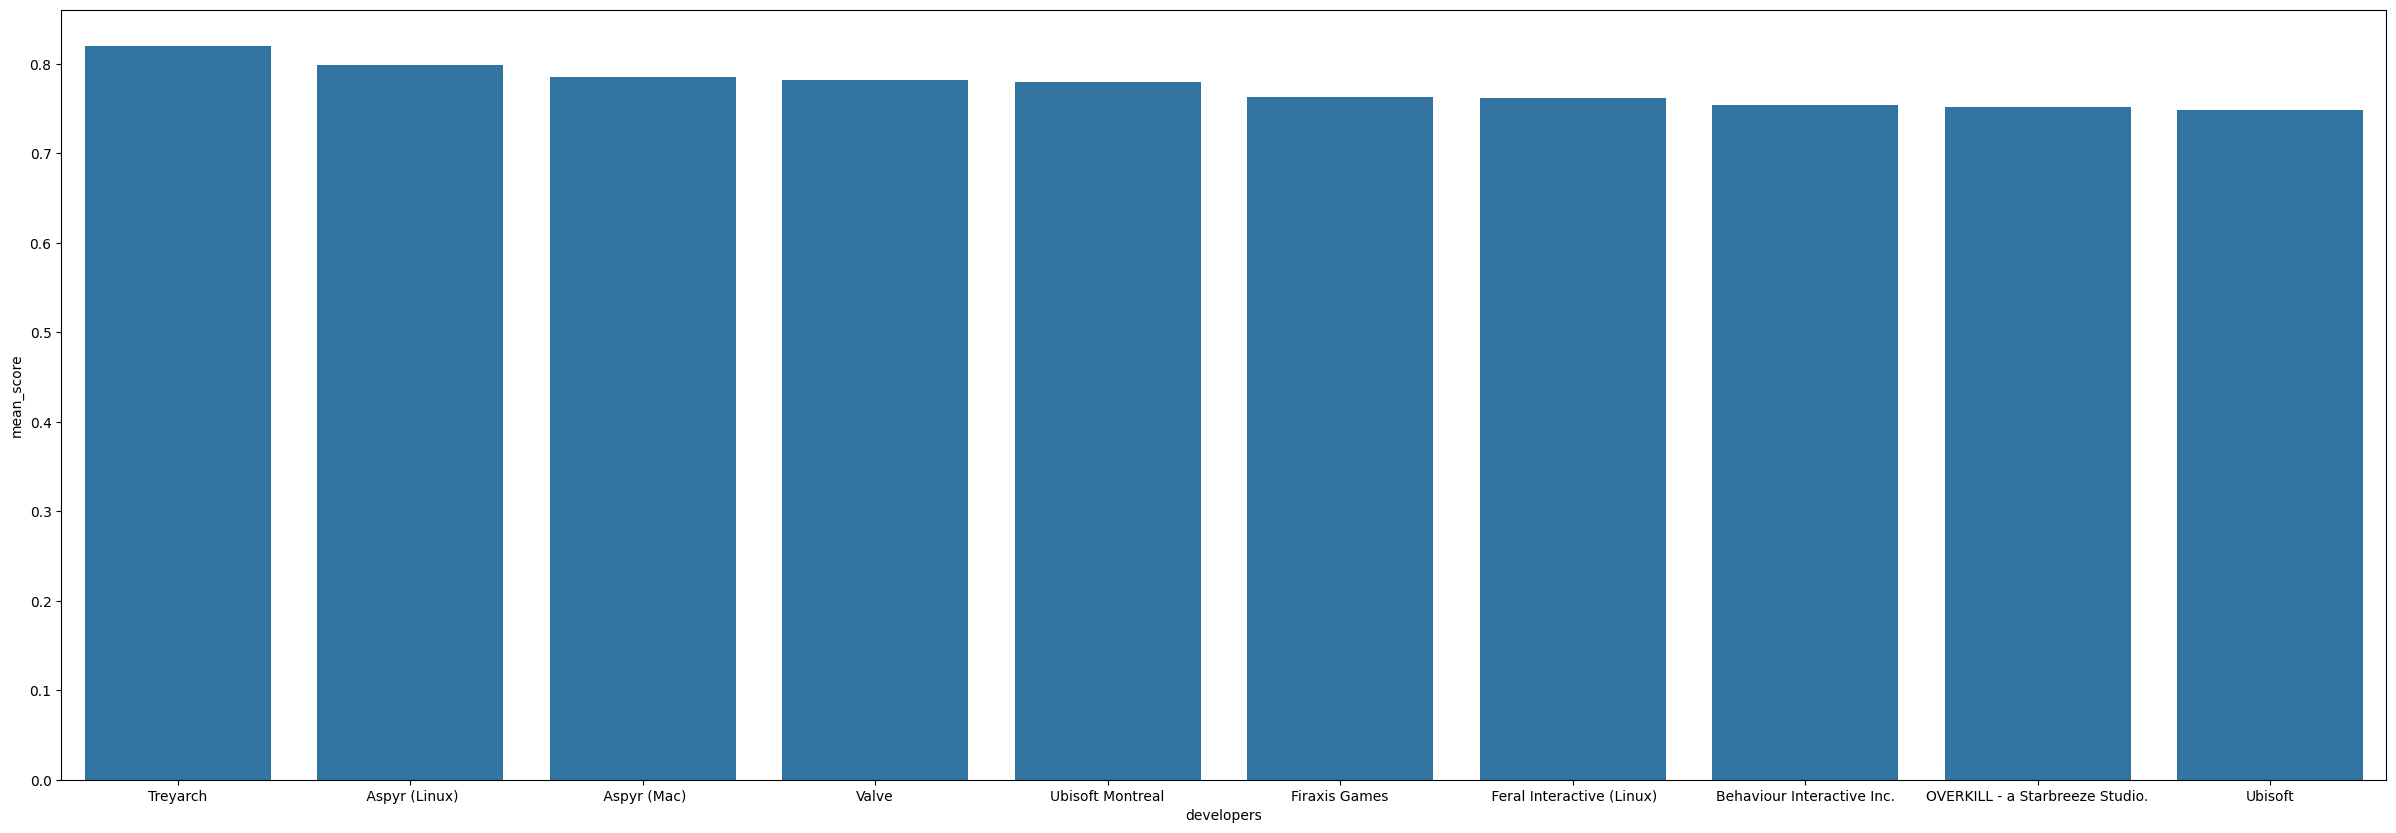

In [118]:
fig, ax = plt.subplots(figsize=(30, 10))
devs = group_developers[group_developers['games_count'] >= 10].sort_values('mean_score', ascending=False).head(10)
sns.barplot(x='developers', y='mean_score', data = devs)

Итого, сделали выводы, что большие команды чаще получают более высокие и стабильные оценки за свои игры, но их довольно мало на рынке, видимо, есть какие-то подводные камни, выше порог входа, ресурсными ограничениями и тд. Также поняли, кто лидеры на рынке и можем на них ориентироваться.